## **Comparación de Gradiente Descendente y Adam en una Función de Costo No Convexa**

En este ejercicio se compararán los optimizadores Gradiente Descendente (GD) y Adam en la minimización de una función de costo basada en una red neuronal de una sola conexión sináptica:
$$
z = w x + b
$$
Con función de activación tangente hiperbólica:

$$
\hat{y} = a(z) = \tanh(z) = \tanh(w x + b)
$$

<br>

Se analizará la trayectoria de aprendizaje de ambos algoritmos y se evaluará su eficiencia con diferentes tasas de aprendizaje (learning rate).

<br>

La función de costo utilizada es el Error Cuadrático Medio (MSE):

$$
J(w, b) = \frac{1}{m} \sum_{i=1}^{m} (\hat{y}_i - y_i)^2
$$

$$
J(w, b) = \frac{1}{m} \sum_{i=1}^{m} ( \tanh(w x_i + b) - y_i )^2
$$

donde \\( w \\) y \\( b \\) son los parámetros a optimizar.

<br>

Si bien es cierto, en estos experimentos buscamos tan solo comparar optimizadores (GD vs Adam), de igual forma se necesitará una especie de dataset. Este será sintético y solo de prueba, por ende tendrán cierta libertad para elegir sus valores. Sin embargo deberán tomar en cuenta que cumpla la siguiente estructura:

`x = np.linspace(ini, fin, n)`

donde `x` es un array de una sola dimensión y con `n` cantidad de valores ($n>=200$). Y tiene un rango de valores desde `ini` hasta `fin`. Recomiendo que sea simétrico, es decir, los mismos valores solo que con el signo cambiado, por ejemplo `ini=-3, fin=3`, `ini=-5, fin=5`, `ini=-10, fin=10`, etc. Queda a elección de ustedes.

<br>

Y con un target `y`:

`y = funcion_no_lineal(x) + ruido`

donde `y` es también un vector de una sola dimensión de tamaño `n` que sigue un patrón no lineal (elegido por ustedes) con respecto a `x` adicionando un ruido que puede ser creado con algunas de las funciones del paquete `np.random`.

El patrón no lineal puede ser una función trigonométrica, exponencial, logarítmica, sigmoidal, polinómica de grado mayor o igual a 3, o la combinación de varias de estas (recomendado). Pero sean prudentes en la elección de la función no lineal, ya que recuerden que es una red de una sola conexión, por ende tampoco elijan algo tan complejo que al final provoque que el modelo no pueda converger.

### 1a) Implementación del Gradiente Descendente (1 punto)
- Implementar el algoritmo del Gradiente Descendente (GD) para minimizar \\( J(w, b) \\).
- Utilizar 100 épocas y 3 diferentes learning rates `(0.1, 0.01, 0.001)`.
- Inicializar valores de \\( w \\) y \\( b \\) de manera aleatoria con `np.random.randn()`.
- Graficar la función de Costo \\( J(w, b) \\) VS número de época para comparar cómo converge la función para los 3 learning rates. Las 3 gráficas deben estar en el mismo plot para que la comparación visual sea más fácil.

<br>

El optimizador del Gradiente Descendente se debe implementar haciendo el código desde cero y paso a paso. Se pueden usar librerías como `numpy`, `scipy`, `matplotlib` o similares. Pero no está permitido usar PyTorch ni TensorFlow o frameworks que ya contengan el optimizador desarrollado.

In [337]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML, display
import seaborn as sns

$$
\text{Al tener una función de activación}  \tanh(z) \text{las derivadas nos quedarán}: 
$$

$$
\frac{\partial J}{\partial w} = -\frac{2}{n} \sum_{i=1}^{n} (y_i - \hat y_i) \frac{(x)}{cosh^{2}(wx+b)}\
$$

$$
\frac{\partial J}{\partial b} = -\frac{2}{n} \sum_{i=1}^{n} (y_i - \hat y_i)\frac{(1)}{cosh^{2}(wx+b)}\
$$

Pero sabiendo que: 

$$
cosh^{2}(z) - senh^{2}(z) = 1
$$

Podeos dividir todo por:
$$
cosh^{2}(z)
$$

Llegando a: 
$$
1 - \frac{senh^{2}(z)}{cosh^{2}(z)} = \frac{1}{cosh^{2}(z)}
$$
$$
1 - {tanh^{2}(z)} = \frac{1}{cosh^{2}(z)}
$$
$$
1 - {{\hat y}^{2}} = \frac{1}{cosh^{2}(z)}
$$

<p>Se opta por esta útlima forma de escribir el gradiente ya que conlleva dos beneficios:<li>Mayor simplicidad: no debemos usar la variable intermedia "z" dentro del código <li>Evitar errores matemáticos: utilzar "np.cosh" puede causar errores de overlfow</p>


In [ ]:
#Global Variables (will be reused on the other algorithms)

#Function defintions
def predict(W,B,X):
    """
    @fn:    predict
    @brief: calculates the y_hat vector of predictions
    @params: 
        W: weights | B: bias | X: input data 
    @returns: y_hat 
    """
    z = W*X+B 
    a = np.tanh(z)
    return a

def getCost(y,y_hat):
    """
    @fn:    getCost 
    @brief: calculates the cost function given a label and a prediction calculated by the model
    @params: 
        y: ground truth | y_hat: prediction
    @returns: loss 
    """
    
    return np.mean((y-y_hat)**2)


def dC_dZ(y,y_hat,X):
    """
    @fn:    dC_dZ
    @brief: computes the gradient of the loss function
    @params: 
        W: weights | B: bias
    @return dC_dW | dC_dB
    """

    n = len(X)

    #compute the error (only once) and store it into "err"
    err = (y-y_hat)


    #gradients with cosh:
    #dC_dW = np.sum(err * X/( (np.cosh(z))**2 ))
    #dC_dW = (-2/n)*(dC_dW)
    #dC_dB = np.sum(err/( (np.cosh(z))**2 ))
    #dC_dB = (-2/n)*(dC_dB)


    dC_dW = np.sum(err * X * (1-y_hat**2) )
    dC_dW = (-2/n)*(dC_dW)
    dC_dB = np.sum(err * (1-y_hat**2))
    dC_dB = (-2/n)*(dC_dB)

    return dC_dW,dC_dB

def non_lineal(X,noise,type):
    """
    @fn:    non_lineal
    @brief: non-lineal function to generate the ground truth from X
    @params: 
        X: dataset | type: type of function to apply
    @return y
    """
    if type=="polinomical":
        return (0.001)*X**3+(0.01)X**2+(0.1)*X+noise
    if type=="sigmoid":
        return (1/(1+np.exp(-X)))+noise



##### *Main program* #####

#define sintetic dataset
ini = 5
end = -ini
dataset_size = 300
X = np.linspace(ini,end,dataset_size)

#instantieate random generator
seed = 14
rng = np.random.default_rng(seed=seed)


#generate ground truth
median = 0
deviation  = 0.1
noise = rng.normal(median,deviation,size=dataset_size) #in ML we usually model noise as a "Gaussian Noise"! 
y = non_lineal(X,noise,type="sigmoid")

#train parameters

lrs = [0.1, 0.01, 0.001] #generate list with the learning rates
epochs = 100             #initialize epochs number
W0 = np.random.randn()   #generate random number to initialize the weights 
B0 = np.random.randn()   #generate random number to initialize the bias   


#initialize the parameters history arrays
path_w = []
path_b = []
path_C = []
for _ in range(len(lrs)):
    path_w.append([])
    path_b.append([])
    path_C.append([])



#implement the Gradient Descent Algorithm (GD): we have to do it for each lr
for i in range(len(lrs)):
    #get the lr 
    lr = lrs[i]
    
    #for each lr we re-initialize the parameters
    W = W0
    B = B0
    
    #obtain the predictions for the current set of parameters
    y_hat = predict(W,B,X)
        
    #compute the cost
    c = getCost(y,y_hat=y_hat)


    #store the first parameters values of this lr and epoch
    path_w[i].append(W)
    path_b[i].append(B)
    path_C[i].append(c)

    #we compute all the epochs for each lr
    for epoch in range(epochs-1):

        #compute the gradient
        dC_dW,dC_dB = dC_dZ(y,y_hat,X)
        
        #update the parameters
        W = W - lr*dC_dW
        B = B - lr*dC_dB

        #obtain the predictions for the current set of parameters
        y_hat = predict(W,B,X)
        
        #compute the cost
        c = getCost(y,y_hat=y_hat)

        #store epoch values
        path_w[i].append(W)
        path_b[i].append(B)
        path_C[i].append(c)





    #path_w = np.array([np.array(xi) for xi in path_w])
    #path_b = np.array(path_b)
    #path_C = np.array(path_C)

    

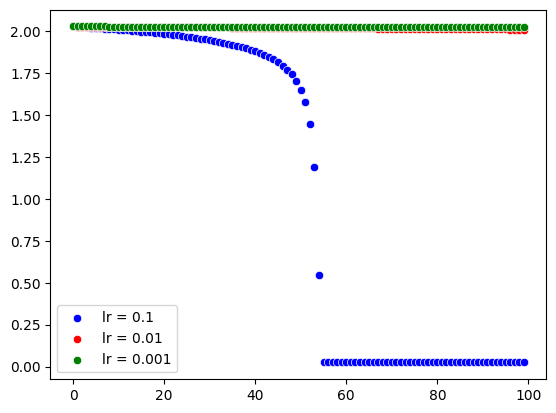

In [335]:
#2D loss graph
sns.scatterplot(x=np.arange(0,len(path_C[0]),1),y=path_C[0],label="lr = 0.1",color="blue")
sns.scatterplot(x=np.arange(0,len(path_C[1]),1),y=path_C[1],label="lr = 0.01",color="red")
sns.scatterplot(x=np.arange(0,len(path_C[2]),1),y=path_C[2],label="lr = 0.001",color="green")
plt.show()

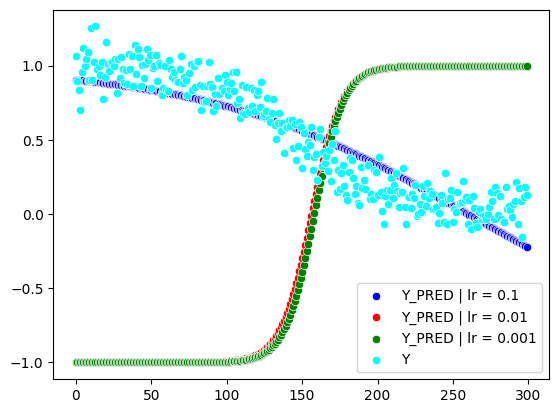

In [336]:
#lets check how we are aproximating the ground truth
Y_PRED_1 = np.tanh(path_w[0][-1]*X+path_b[0][-1])
Y_PRED_2 = np.tanh(path_w[1][-1]*X+path_b[1][-1])
Y_PRED_3 = np.tanh(path_w[2][-1]*X+path_b[2][-1])

sns.scatterplot(x=np.arange(0,len(Y_PRED_1),1),y=Y_PRED_1,label='Y_PRED | lr = 0.1',color='blue')
sns.scatterplot(x=np.arange(0,len(Y_PRED_2),1),y=Y_PRED_2,label='Y_PRED | lr = 0.01',color='red')
sns.scatterplot(x=np.arange(0,len(Y_PRED_3),1),y=Y_PRED_3,label='Y_PRED | lr = 0.001',color='green')
sns.scatterplot(x=np.arange(0,len(y),1),y=y,label='Y',color='cyan')

plt.show()

Podemos observar que el modelo con el lr mayor (0.1) fue el que más minimizó el costo y mejor se ajustó a la función objetivo. En principio, se podría haber esperado que un lr menor, fuera más performante, pero en realidad lo que sucede es que los lr menores aprenden más lento y al utilizar un número de épocas (relativamente) "bajo", estos modelos no tuvieron el tiempo suficiente para aprender.

### 1b) Implementación de Adam (2 punto)  
- Implementar el algoritmo de Adam para minimizar \\( J(w, b) \\).  
- Utilizar 100 épocas y 3 diferentes learning rates `(0.1, 0.01, 0.001)`.
- Utilizar los mismos valores de \\( w \\) y \\( b \\) que se usaron para GD **(IMPORTANTE)**.
- Hacer 2 modelos, uno sin mini-batch (full-batch) y otro con mini-batch.
- El batch size es a elección de ustedes, pero debe ser mayor o igual a 16.
- Graficar la función de Costo \\( J(w, b) \\) VS número de época para comparar cómo converge la función para ambos modelos y para los 3 learning rates. Deben haber 2 plots separados o 2 subplots, uno para las 3 gráficas de Adam full-batch y otro para las 3 gráficas de Adam mini-batch.

<br>

Al igual que para GD, ambas versiones del optimizador Adam también se deben implementar desde cero y paso a paso. Se pueden usar librerías como `numpy`, `scipy`, `matplotlib` o similares. Pero no está permitido usar PyTorch ni TensorFlow o frameworks que ya contengan el optimizador desarrollado.

<h2><b>Implementación Adam Full-Batch

In [387]:
#Function definition

##### *Main program* #####

#define sintetic dataset
ini = 5
end = -ini
dataset_size = 300
X = np.linspace(ini,end,dataset_size)

#instantieate random generator
seed = 14
rng = np.random.default_rng(seed=seed)


#generate ground truth
median = 0
deviation  = 0.1
noise = rng.normal(median,deviation,size=dataset_size) #in ML we usually model noise as a "Gaussian Noise"! 
y = non_lineal(X,noise,type="sigmoid")

#train parameters
beta_1 = 0.9
beta_2 = 0.999
epsilon = 1e-8
lrs = [0.1, 0.01, 0.001] #generate list with the learning rates
epochs = 100            #initialize epochs number
m_w = 0                   #initialize gradient median memory for the weights
m_b = 0                   #initialize gradient median memory for the biases
m_w_hat = 0               #initialize un-biased m_w
m_b_hat = 0               #initialize un-biased m_b
v_w = 0                   #initialize gradient^2 median for the weights
v_b = 0                   #initialize gradient^2 median for the biases
v_w_hat = 0               #initialize un-biased v_w
v_b_hat = 0               #initialize un-biased v_b

#W0 and B0 already initialized in DG 


#initialize the parameters history arrays
path_w = []
path_b = []
path_C = []
for _ in range(len(lrs)):
    path_w.append([])
    path_b.append([])
    path_C.append([])



#implement the ADAM Full batch (GD): we have to do it for each lr
for i in range(len(lrs)):
    #get the lr 
    lr = lrs[i]

    #re-initialize m and v
    m_w = 0                   #initialize gradient median memory for the weights
    m_b = 0                   #initialize gradient median memory for the biases
    m_w_hat = 0               #initialize un-biased m_w
    m_b_hat = 0               #initialize un-biased m_b
    v_w = 0                   #initialize gradient^2 median for the weights
    v_b = 0                   #initialize gradient^2 median for the biases
    v_w_hat = 0               #initialize un-biased v_w
    v_b_hat = 0               #initialize un-biased v_b
    
    #for each lr we re-initialize the parameters
    W = W0
    B = B0
    
    #obtain the predictions for the current set of parameters
    y_hat = predict(W,B,X)
        
    #compute the cost
    c = getCost(y,y_hat=y_hat)

    #calculate the first m_t and v_t
   # m_t = (1-beta_1)*c
   # v_t = (1-beta_2)*(c**2)

    #correct bias (TODO: check if neccessary on this step)
   # m_hat = (m_t)/((1-beta_1))
   # v_hat = (v_t)/(1-beta_2)

    #store the first parameters values of this lr and epoch
    path_w[i].append(W)
    path_b[i].append(B)
    path_C[i].append(c)

    #we compute all the epochs for each lr
    for epoch in range(epochs-1):
        epoch+=1
        #compute the gradient
        dC_dW,dC_dB = dC_dZ(y,y_hat,X)
        
        #calculate the first m_t and v_t
        m_w = beta_1*m_w+(1-beta_1)*dC_dW
        v_w = beta_2*v_w+(1-beta_2)*(dC_dW**2)
        m_b = beta_1*m_b+(1-beta_1)*dC_dB
        v_b = beta_2*v_b+(1-beta_2)*(dC_dB**2)        

        #correct bias
        m_w_hat = (m_w)/((1-(beta_1**epoch)))
        v_w_hat = (v_w)/(1-(beta_2**epoch))
        m_b_hat = (m_b)/((1-(beta_1**epoch)))
        v_b_hat = (v_b)/(1-(beta_2**epoch))

        #update the parameters
        W = W - lr*(m_w_hat/(np.sqrt(v_w_hat)+epsilon))
        B = B - lr*(m_b_hat/(np.sqrt(v_b_hat)+epsilon))

        #obtain the predictions for the current set of parameters
        y_hat = predict(W,B,X)
        
        #compute the cost
        c = getCost(y,y_hat=y_hat)

        #store epoch values
        path_w[i].append(W)
        path_b[i].append(B)
        path_C[i].append(c)





    #path_w = np.array([np.array(xi) for xi in path_w])
    #path_b = np.array(path_b)
    #path_C = np.array(path_C)

    

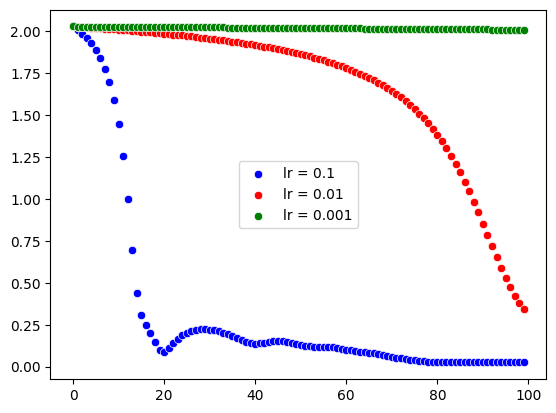

In [388]:
#2D loss graph
sns.scatterplot(x=np.arange(0,len(path_C[0]),1),y=path_C[0],label="lr = 0.1",color="blue")
sns.scatterplot(x=np.arange(0,len(path_C[1]),1),y=path_C[1],label="lr = 0.01",color="red")
sns.scatterplot(x=np.arange(0,len(path_C[2]),1),y=path_C[2],label="lr = 0.001",color="green")
plt.show()

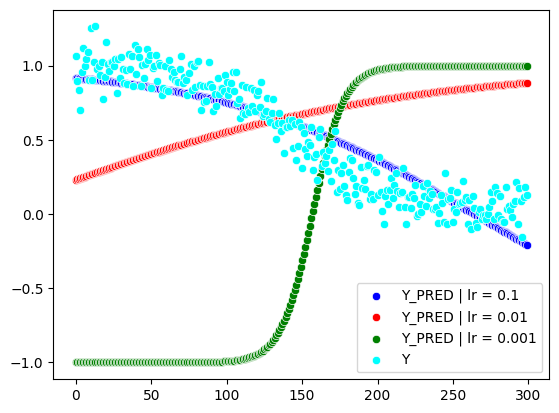

In [389]:
#lets check how we are aproximating the ground truth
Y_PRED_1 = np.tanh(path_w[0][-1]*X+path_b[0][-1])
Y_PRED_2 = np.tanh(path_w[1][-1]*X+path_b[1][-1])
Y_PRED_3 = np.tanh(path_w[2][-1]*X+path_b[2][-1])

sns.scatterplot(x=np.arange(0,len(Y_PRED_1),1),y=Y_PRED_1,label='Y_PRED | lr = 0.1',color='blue')
sns.scatterplot(x=np.arange(0,len(Y_PRED_2),1),y=Y_PRED_2,label='Y_PRED | lr = 0.01',color='red')
sns.scatterplot(x=np.arange(0,len(Y_PRED_3),1),y=Y_PRED_3,label='Y_PRED | lr = 0.001',color='green')
sns.scatterplot(x=np.arange(0,len(y),1),y=y,label='Y',color='cyan')

plt.show()

<h2><b>Implementación Adam Full-Batch